In [3]:
import pandas as pd 

df = pd.read_csv("train.csv", index_col="id")
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
## Quick look at shape and columns
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")


Shape: (630000, 20)

Columns:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

Data types:
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm

In [5]:
## Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct})
print(missing_df[missing_df["Missing"] > 0] if missing.sum() > 0 else "No missing values found.")
print(f"\nTotal missing cells: {missing.sum()}")


No missing values found.

Total missing cells: 0


In [6]:
## Descriptive statistics – numeric features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00


In [7]:
## Descriptive statistics – categorical features
df.describe(include="object").T


,count,unique,top,freq
Soil_Type,630000,4,Sandy,166509
Crop_Type,630000,6,Sugarcane,108910
Crop_Growth_Stage,630000,4,Harvest,167689
Season,630000,3,Kharif,216561
Irrigation_Type,630000,4,Canal,161901
Water_Source,630000,4,Reservoir,162994
Mulching_Used,630000,2,No,316453
Region,630000,5,South,134809
Irrigation_Need,630000,3,Low,369917


/home/oscarm524/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/tmp/ipykernel_232204/1189158137.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette="viridis")
/tmp/ipykernel_232204/1189158137.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[1], palette="viridis")

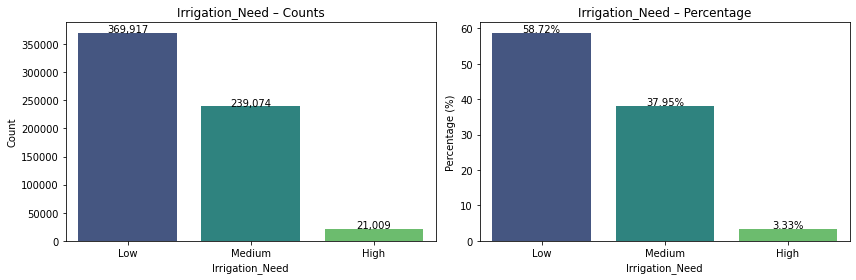

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

## Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts = df["Irrigation_Need"].value_counts()
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Irrigation_Need – Counts")
axes[0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

# Percentage
target_pct = (target_counts / len(df) * 100).round(2)
sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[1], palette="viridis")
axes[1].set_title("Irrigation_Need – Percentage")
axes[1].set_ylabel("Percentage (%)")
for i, v in enumerate(target_pct.values):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


In [9]:
## Unique values per categorical feature
cat_cols = df.select_dtypes(include="object").columns.drop("Irrigation_Need")

for col in cat_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())



--- Soil_Type (4 unique) ---
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64

--- Crop_Type (6 unique) ---
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64

--- Crop_Growth_Stage (4 unique) ---
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64

--- Season (3 unique) ---
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64

--- Irrigation_Type (4 unique) ---
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64

--- Water_Source (4 unique) ---
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64

--- Mulching_Used (2 unique) ---
Mulching_Used
No     316453
Yes    313547
Name: count, 

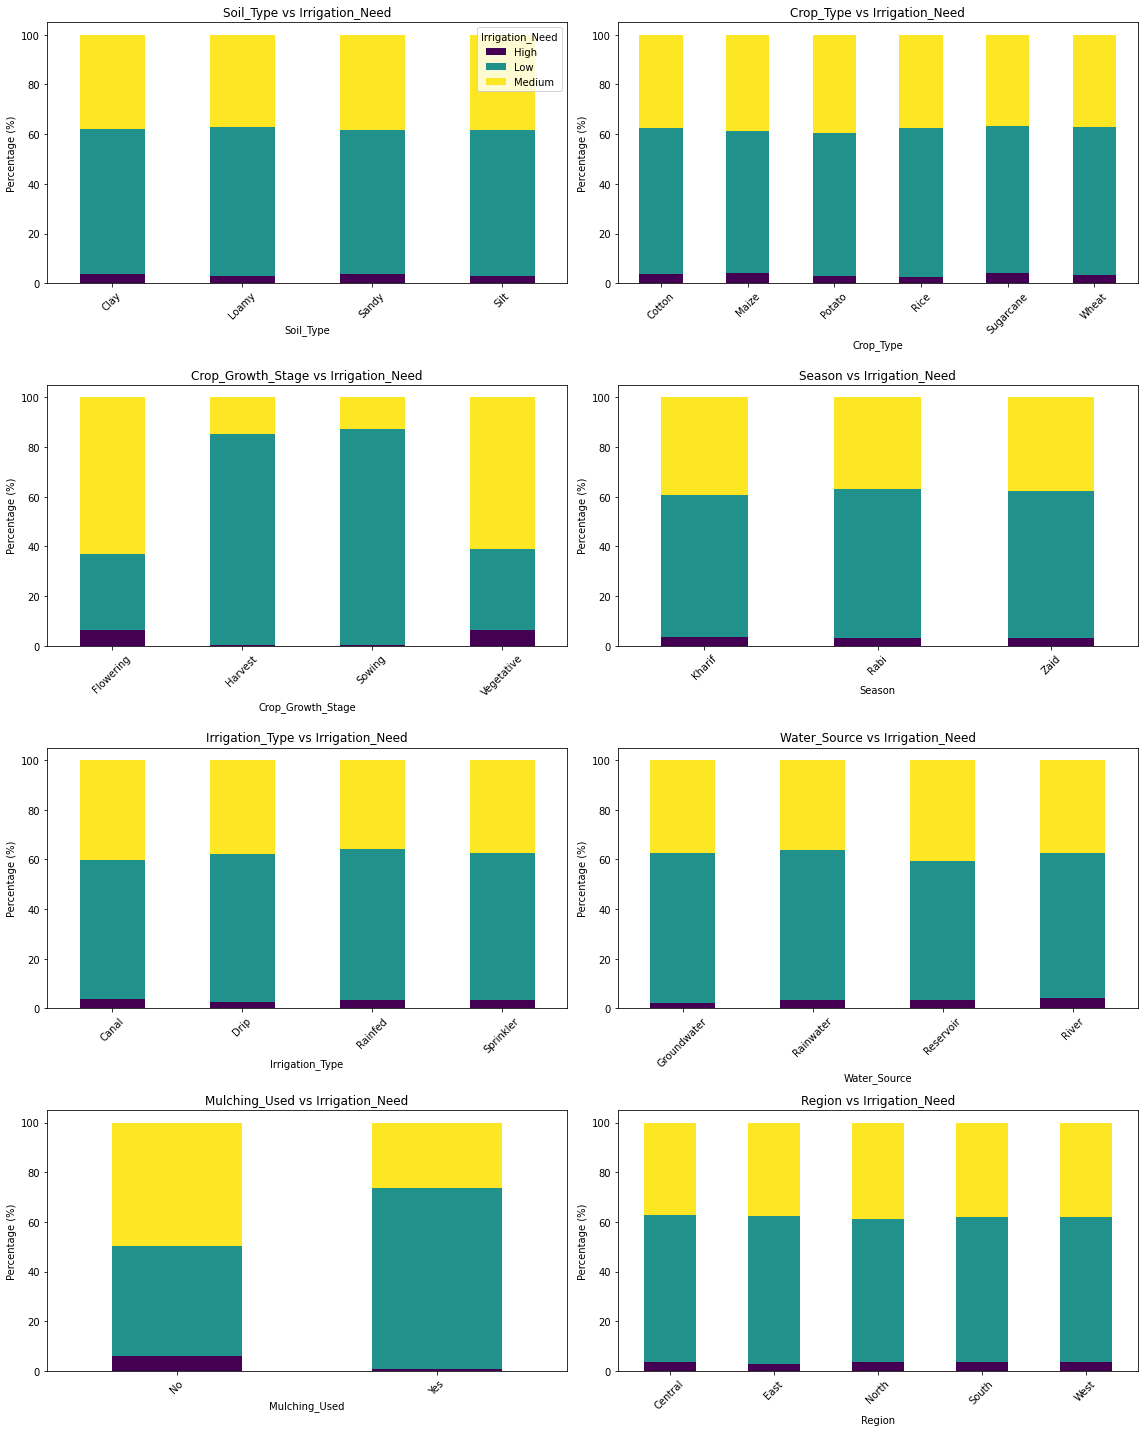

In [10]:
## Categorical features vs Target (stacked percentage bar charts)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Irrigation_Need"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="viridis", legend=(i == 0))
    axes[i].set_title(f"{col} vs Irrigation_Need")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=45)

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


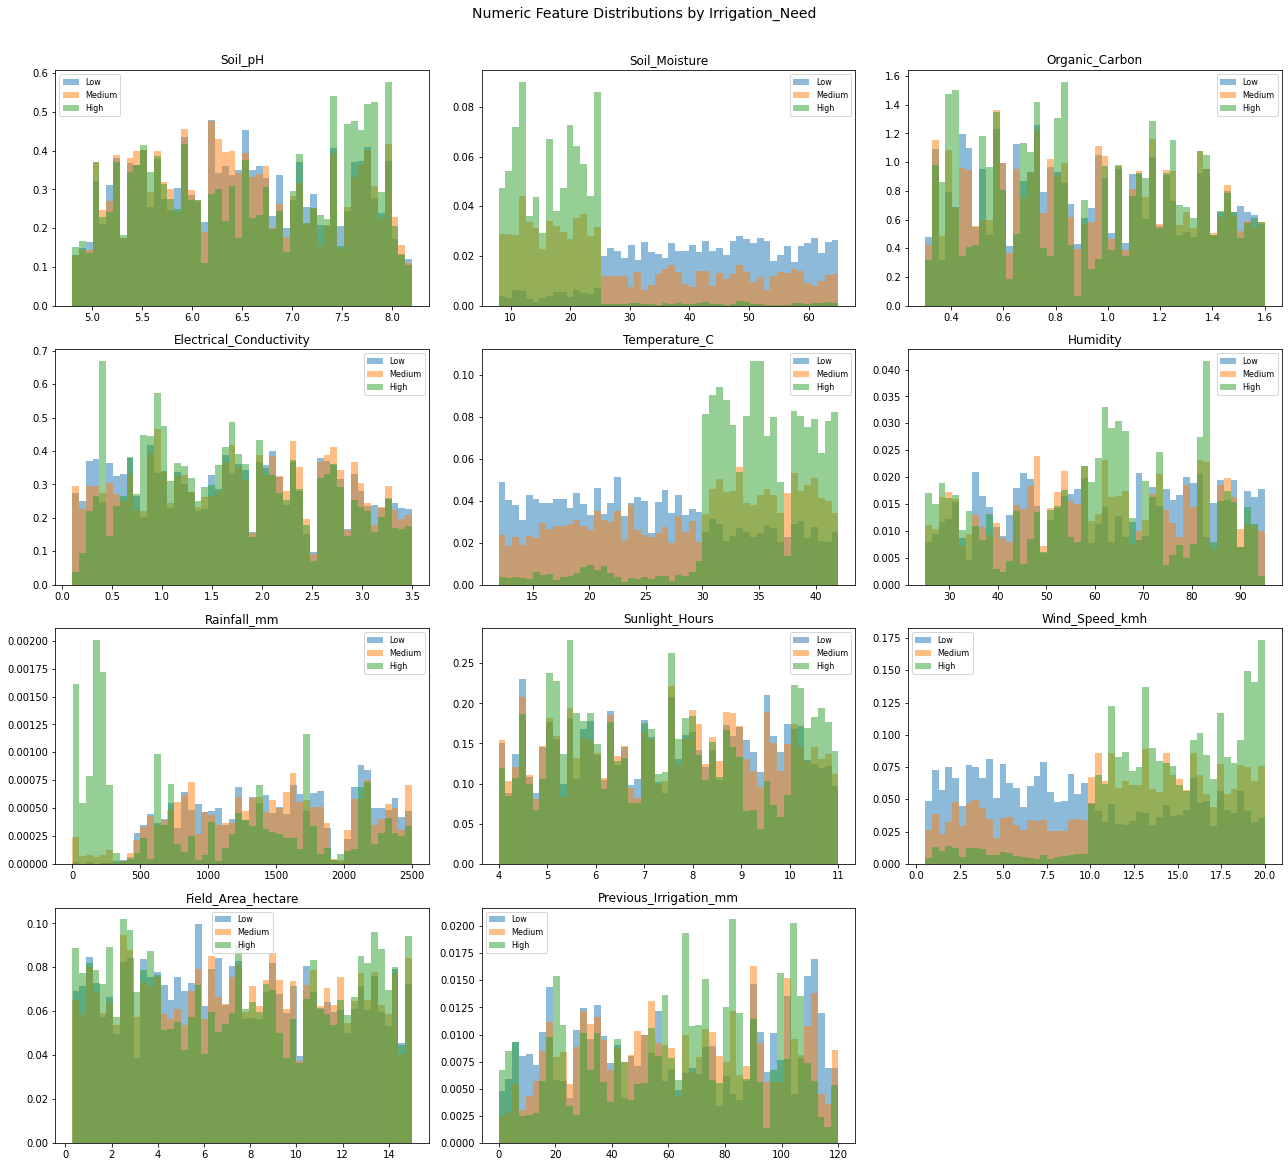

In [11]:
## Numeric feature distributions by target
num_cols = df.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label in df["Irrigation_Need"].unique():
        subset = df[df["Irrigation_Need"] == label][col]
        axes[i].hist(subset, bins=50, alpha=0.5, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions by Irrigation_Need", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


/tmp/ipykernel_232204/2105630431.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Irrigation_Need", y=col, ax=axes[i], palette="viridis")
/tmp/ipykernel_232204/2105630431.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Irrigation_Need", y=col, ax=axes[i], palette="viridis")
/tmp/ipykernel_232204/2105630431.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Irrigation_Need", y=col, ax=axes[i], palette="viridis")
/tmp/ipykernel_232204/2105630431.py:6: FutureWarning: 

Passing `palette` without assign

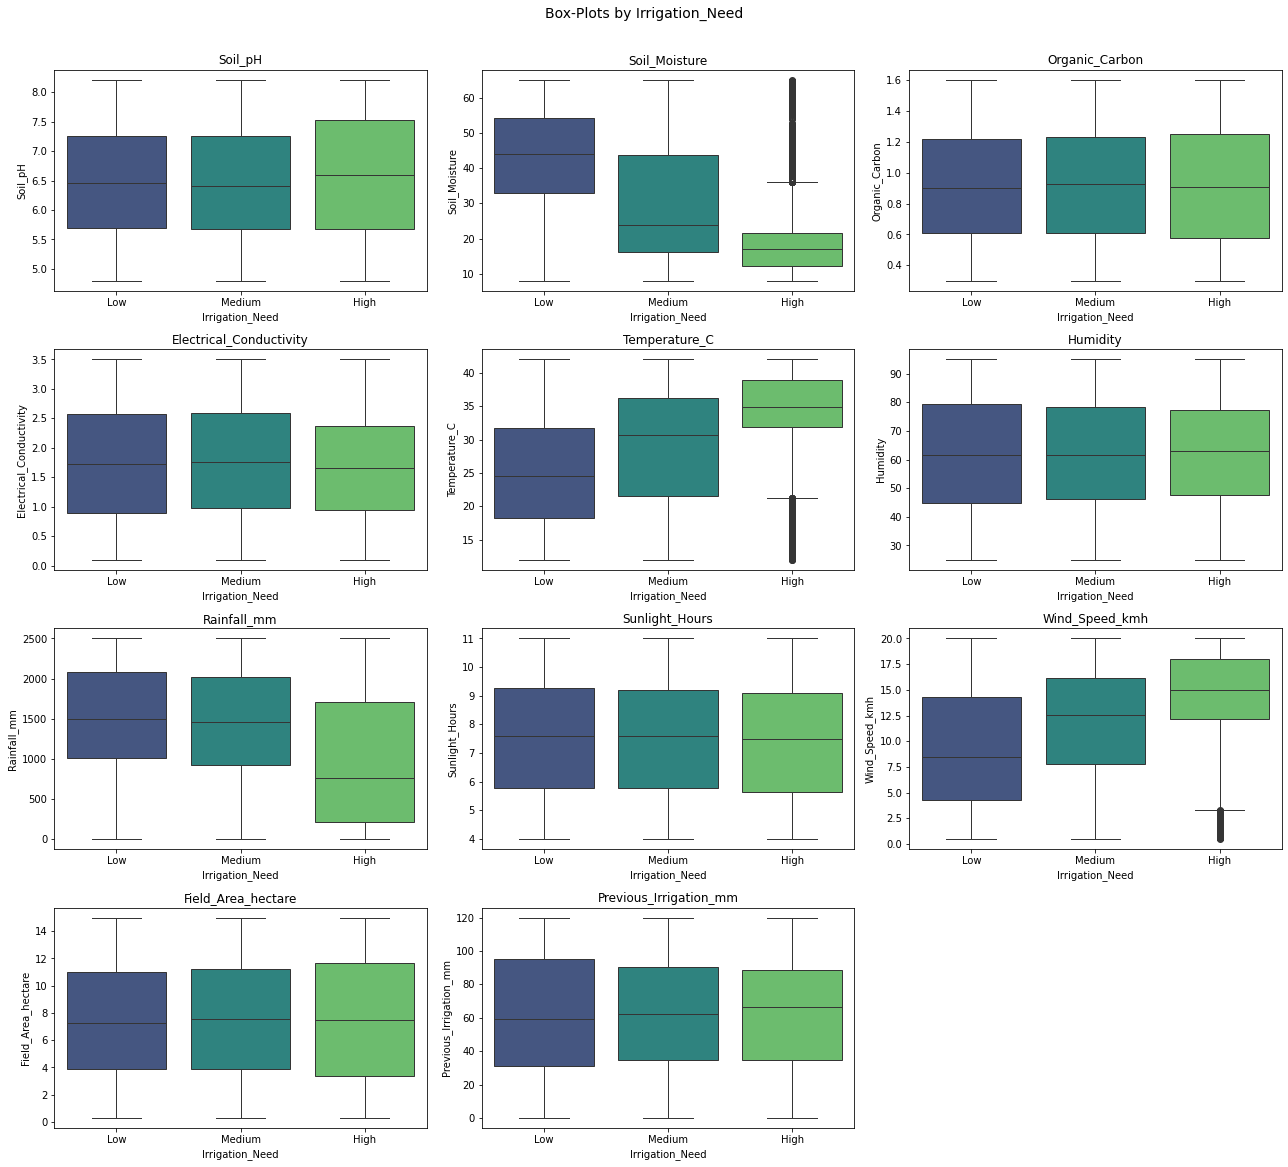

In [12]:
## Box-plots of numeric features by target
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Irrigation_Need", y=col, ax=axes[i], palette="viridis")
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box-Plots by Irrigation_Need", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


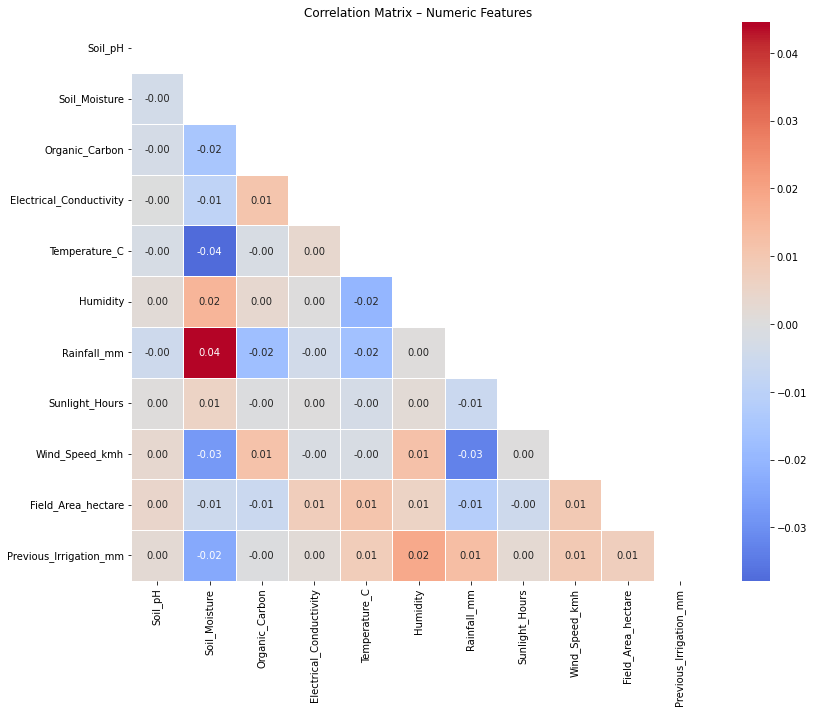

In [13]:
## Correlation heatmap (numeric features)
import numpy as np

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix – Numeric Features")
plt.tight_layout()
plt.show()


/tmp/ipykernel_232204/1369549027.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cramers_df["Cramér's V"], y=cramers_df.index, palette="viridis", ax=ax)


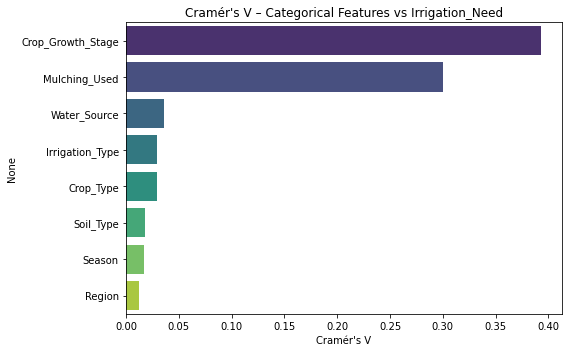

                   Cramér's V
Crop_Growth_Stage    0.392771
Mulching_Used        0.300468
Water_Source         0.036107
Irrigation_Type      0.029499
Crop_Type            0.029479
Soil_Type            0.017958
Season               0.017216
Region               0.012232


In [14]:
## Cramér's V between each categorical feature and the target
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramers = {col: cramers_v(df[col], df["Irrigation_Need"]) for col in cat_cols}
cramers_df = pd.DataFrame.from_dict(cramers, orient="index", columns=["Cramér's V"]).sort_values("Cramér's V", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=cramers_df["Cramér's V"], y=cramers_df.index, palette="viridis", ax=ax)
ax.set_title("Cramér's V – Categorical Features vs Irrigation_Need")
ax.set_xlabel("Cramér's V")
plt.tight_layout()
plt.show()

print(cramers_df)


In [15]:
## Numeric feature aggregates by target class
agg = df.groupby("Irrigation_Need")[num_cols].agg(["mean", "median", "std"]).T
agg


Irrigation_Need                       High          Low       Medium
Soil_pH                 mean      6.578282     6.487805     6.465867
                        median    6.590000     6.460000     6.400000
                        std       0.978948     0.916681     0.925763
Soil_Moisture           mean     17.669875    43.305902    29.743961
                        median   17.090000    44.010000    23.890000
                        std       7.479613    13.421279    16.624592
Organic_Carbon          mean      0.924143     0.920680     0.926116
                        median    0.910000     0.900000     0.930000
                        std       0.373870     0.365927     0.364882
Electrical_Conductivity mean      1.690880     1.731755     1.769208
                        median    1.650000     1.720000     1.760000
                        std       0.891465     0.961384     0.942780
Temperature_C           mean     34.568134    25.347708    28.886683
                        median   34.910000    24.540000    30.660000
                        std       5.420716     8.364835     8.503269
Humidity                mean     61.119576    61.949194    61.004887
                        median   62.850000    61.770000    61.440000
                        std      19.242509    19.913072    19.413552
Rainfall_mm             mean    989.156678  1500.534313  1444.475028
                        median  764.950000  1498.880000  1463.590000
                        std     800.312437   584.804731   618.449689
Sunlight_Hours          mean      7.463138     7.511125     7.521290
                        median    7.480000     7.580000     7.610000
                        std       2.030893     2.000223     1.995064
Wind_Speed_kmh          mean     14.642639     9.216424    11.793668
                        median   15.010000     8.420000    12.520000
                        std       4.118403     5.632220     5.388586
Field_Area_hectare      mean      7.530391     7.447241     7.625725
                        median    7.490000     7.250000     7.560000
                        std       4.476655     4.197295     4.224577
Previous_Irrigation_mm  mean     63.053300    61.718330    63.181715
                        median   66.650000    59.380000    62.200000
                        std      32.197213    35.548062    32.295011

In [16]:
## Duplicate rows
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup} ({n_dup / len(df) * 100:.2f}%)")

## Skewness & Kurtosis
sk = df[num_cols].skew().round(3)
ku = df[num_cols].kurtosis().round(3)
sk_ku = pd.DataFrame({"Skewness": sk, "Kurtosis": ku})
print("\nSkewness & Kurtosis:")
print(sk_ku)


Duplicate rows: 0 (0.00%)

Skewness & Kurtosis:
                         Skewness  Kurtosis
Soil_pH                     0.070    -1.145
Soil_Moisture              -0.064    -1.181
Organic_Carbon              0.105    -1.166
Electrical_Conductivity     0.048    -1.148
Temperature_C              -0.004    -1.206
Humidity                   -0.089    -1.164
Rainfall_mm                -0.118    -0.940
Sunlight_Hours             -0.035    -1.206
Wind_Speed_kmh             -0.028    -1.242
Field_Area_hectare          0.052    -1.176
Previous_Irrigation_mm     -0.017    -1.255


In [18]:
## ===================== EXECUTIVE SUMMARY =====================

from IPython.display import Markdown, display

target_counts = df["Irrigation_Need"].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)
n_dup = df.duplicated().sum()
missing_total = df.isnull().sum().sum()

# Top Cramér's V features
cramers_sorted = cramers_df.sort_values("Cramér's V", ascending=False)
top_cat = cramers_sorted.head(3)

# Highly correlated numeric pairs (|r| > 0.5)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

summary = f"""
# 📋 Executive Summary – Exploratory Data Analysis

## Dataset Overview
- **Rows:** {len(df):,} | **Columns:** {df.shape[1]}
- **Numeric features:** {len(num_cols)} | **Categorical features:** {len(cat_cols)} (+ target)
- **Target:** `Irrigation_Need` (classification with 3 classes: Low, Medium, High)
- **Missing values:** {missing_total}
- **Duplicate rows:** {n_dup:,} ({n_dup / len(df) * 100:.2f}%)

## Target Distribution
| Class | Count | Percentage |
|-------|------:|----------:|
"""
for cls in target_counts.index:
    summary += f"| {cls} | {target_counts[cls]:,} | {target_pct[cls]}% |\n"

balance_ratio = target_pct.min() / target_pct.max()
if balance_ratio > 0.8:
    balance_note = "The target classes are **well balanced**."
elif balance_ratio > 0.5:
    balance_note = "The target classes show **moderate imbalance**."
else:
    balance_note = "The target classes are **imbalanced**; consider stratified sampling or resampling techniques."

summary += f"\n{balance_note}\n"

summary += """
## Categorical Features & Association with Target
Top features by Cramér's V:

| Feature | Cramér's V |
|---------|----------:|
"""
for feat, row in top_cat.iterrows():
    cv = row["Cramér's V"]
    summary += f"| {feat} | {cv:.4f} |\n"

summary += """
## Numeric Feature Correlations
"""
if high_corr_pairs:
    summary += "Pairs with |correlation| > 0.5:\n\n| Feature 1 | Feature 2 | Correlation |\n|-----------|-----------|------------:|\n"
    for f1, f2, r in high_corr_pairs:
        summary += f"| {f1} | {f2} | {r} |\n"
else:
    summary += "No numeric feature pairs exhibit a correlation above |0.5|, suggesting **low multicollinearity** among predictors.\n"

summary += """
## Key Numeric Feature Differences by Target
- **Soil_Moisture:** Strong separator — High-need fields average ~18%, Medium ~30%, Low ~43%.
- **Temperature_C:** High-need fields are notably hotter (mean ~35°C) vs Low (~25°C).
- **Wind_Speed_kmh:** High-need fields experience higher wind (mean ~15 km/h) vs Low (~9 km/h).
- **Rainfall_mm:** High-need fields receive less rain (mean ~989 mm) vs Low (~1501 mm).
- Other numeric features (Humidity, Sunlight_Hours, Organic_Carbon, Previous_Irrigation_mm) show little separation across classes.

## Key Takeaways
1. The dataset is **clean** — no missing values, no duplicates.
2. The target is **imbalanced** (Low ≈ 59%, Medium ≈ 38%, High ≈ 3%) — consider stratified CV, class weights, or oversampling for the minority class.
3. **Crop_Growth_Stage** (V = 0.39) and **Mulching_Used** (V = 0.30) are the most informative categorical features.
4. **Soil_Moisture, Temperature_C, Wind_Speed_kmh, and Rainfall_mm** show the clearest numeric separation across target classes — these are likely the strongest predictors.
5. Numeric features are **nearly uncorrelated** (max |r| < 0.05), so multicollinearity is not a concern.
6. All numeric distributions are roughly **uniform** (negative kurtosis ≈ −1.2), not Gaussian — tree-based models (XGBoost, LightGBM, CatBoost) are well-suited.
7. Feature engineering (e.g., Soil_Moisture × Temperature_C interaction, rainfall bins) may further boost performance.
"""

display(Markdown(summary))



# 📋 Executive Summary – Exploratory Data Analysis

## Dataset Overview
- **Rows:** 630,000 | **Columns:** 20
- **Numeric features:** 11 | **Categorical features:** 8 (+ target)
- **Target:** `Irrigation_Need` (classification with 3 classes: Low, Medium, High)
- **Missing values:** 0
- **Duplicate rows:** 0 (0.00%)

## Target Distribution
| Class | Count | Percentage |
|-------|------:|----------:|
| Low | 369,917 | 58.72% |
| Medium | 239,074 | 37.95% |
| High | 21,009 | 3.33% |

The target classes are **imbalanced**; consider stratified sampling or resampling techniques.

## Categorical Features & Association with Target
Top features by Cramér's V:

| Feature | Cramér's V |
|---------|----------:|
| Crop_Growth_Stage | 0.3928 |
| Mulching_Used | 0.3005 |
| Water_Source | 0.0361 |

## Numeric Feature Correlations
No numeric feature pairs exhibit a correlation above |0.5|, suggesting **low multicollinearity** among predictors.

## Key Numeric Feature Differences by Target
- **Soil_Moisture:** Strong separator — High-need fields average ~18%, Medium ~30%, Low ~43%.
- **Temperature_C:** High-need fields are notably hotter (mean ~35°C) vs Low (~25°C).
- **Wind_Speed_kmh:** High-need fields experience higher wind (mean ~15 km/h) vs Low (~9 km/h).
- **Rainfall_mm:** High-need fields receive less rain (mean ~989 mm) vs Low (~1501 mm).
- Other numeric features (Humidity, Sunlight_Hours, Organic_Carbon, Previous_Irrigation_mm) show little separation across classes.

## Key Takeaways
1. The dataset is **clean** — no missing values, no duplicates.
2. The target is **imbalanced** (Low ≈ 59%, Medium ≈ 38%, High ≈ 3%) — consider stratified CV, class weights, or oversampling for the minority class.
3. **Crop_Growth_Stage** (V = 0.39) and **Mulching_Used** (V = 0.30) are the most informative categorical features.
4. **Soil_Moisture, Temperature_C, Wind_Speed_kmh, and Rainfall_mm** show the clearest numeric separation across target classes — these are likely the strongest predictors.
5. Numeric features are **nearly uncorrelated** (max |r| < 0.05), so multicollinearity is not a concern.
6. All numeric distributions are roughly **uniform** (negative kurtosis ≈ −1.2), not Gaussian — tree-based models (XGBoost, LightGBM, CatBoost) are well-suited.
7. Feature engineering (e.g., Soil_Moisture × Temperature_C interaction, rainfall bins) may further boost performance.
